# Wprowadzenie do eksperymentu

W tym eksperymencie analizowany jest syntetyczny (pseudo) sygnał audio. Został on wygenerowany jako suma kilku składowych sinusoidalnych o różnych częstotliwościach oraz niewielkiego szumu losowego. Tego typu sygnał dobrze przybliża rzeczywiste sygnały audio, które często można interpretować jako superpozycję fal o różnych częstotliwościach.

Sygnał składa się z N = 1024 próbek, co oznacza, że pojedyncza obserwacja ma wymiar 1024. Innymi słowy, każda próbka sygnału może być traktowana jako punkt w przestrzeni 1024-wymiarowej. Jest to przykład danych wysokowymiarowych, mimo że wizualnie przedstawiamy je jako funkcję czasu.

W celu zastosowania algorytmów redukcji wymiarowości sygnał dzielony jest na mniejsze fragmenty (ramki). Parametr `frame_size = 64` oznacza, że każda ramka zawiera 64 próbki, czyli jest wektorem 64-wymiarowym. Cały sygnał jest więc reprezentowany jako zbiór takich wektorów.

Celem eksperymentu jest porównanie dwóch metod redukcji wymiarowości i kompresji danych:
- PCA (Principal Component Analysis) — metoda adaptacyjna, ucząca się struktury danych,
- DCT (Discrete Cosine Transform) — metoda oparta na stałej bazie funkcji cosinus.

Badanie polega na sprawdzeniu, jak dobrze każda z metod potrafi zredukować wymiar danych przy jednoczesnym zachowaniu informacji. Jako miarę jakości używany jest błąd rekonstrukcji (MSE), czyli różnica między oryginalnym sygnałem a jego odtworzoną wersją.

Kluczowe parametry w eksperymencie:

- `k` — liczba współczynników (wymiar po redukcji); określa stopień kompresji. Mniejsze k oznacza większą kompresję, ale potencjalnie większą utratę informacji.
- `frame_size` — rozmiar pojedynczej ramki sygnału; definiuje lokalny wymiar danych wejściowych dla PCA.
- `N` — całkowita liczba próbek sygnału; określa globalny wymiar danych.

Eksperyment analizuje zależność pomiędzy liczbą zachowanych współczynników k a jakością rekonstrukcji sygnału, co pozwala ocenić efektywność obu metod redukcji wymiarowości.

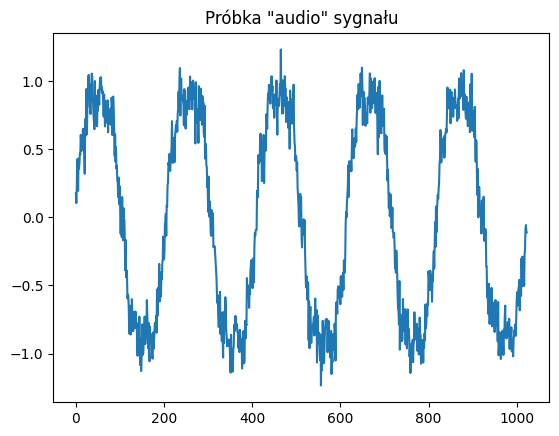

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import dct, idct
plt.style.use('default')
np.random.seed(0)

N = 1024
t = np.linspace(0, 1, N)

signal = (
    np.sin(2*np.pi*5*t) +
    0.1*np.sin(2*np.pi*15*t) +
    0.1*np.sin(2*np.pi*40*t) +
    0.1*np.random.randn(N)
)

plt.plot(signal)
plt.title("Próbka \"audio\" sygnału")
plt.show()

In [11]:
frame_size = 64
frames = signal.reshape(-1, frame_size)  # (16, 64)
n_frames, fs = frames.shape

mean = np.mean(frames, axis=0)
X_centered = frames - mean

U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

max_k = 14 # = 16, limit dla obu metod
ks = list(range(1, max_k + 1))  # [1, 2, ..., 16]

mse_pca_list = []
mse_dct_list = []

for k in ks:
    # ===== PCA =====
    W = Vt.T[:, :k]
    Z = X_centered @ W
    X_rec = Z @ W.T + mean
    mse_pca_list.append(np.mean((signal - X_rec.flatten()) ** 2))

    rec_frames = []
    for frame in frames:
        c = dct(frame, norm="ortho")
        c[k:] = 0
        rec_frames.append(idct(c, norm="ortho"))
    signal_dct_rec = np.array(rec_frames).flatten()
    mse_dct_list.append(np.mean((signal - signal_dct_rec) ** 2))

    print(f"k={k:2d} | MSE_pca={mse_pca_list[-1]:.6f} | MSE_dct={mse_dct_list[-1]:.6f}")

k= 1 | MSE_pca=0.148242 | MSE_dct=0.158286
k= 2 | MSE_pca=0.016148 | MSE_dct=0.027436
k= 3 | MSE_pca=0.010034 | MSE_dct=0.015399
k= 4 | MSE_pca=0.006761 | MSE_dct=0.014103
k= 5 | MSE_pca=0.005399 | MSE_dct=0.011190
k= 6 | MSE_pca=0.004476 | MSE_dct=0.010798
k= 7 | MSE_pca=0.003739 | MSE_dct=0.008786
k= 8 | MSE_pca=0.003038 | MSE_dct=0.008641
k= 9 | MSE_pca=0.002433 | MSE_dct=0.008397
k=10 | MSE_pca=0.001880 | MSE_dct=0.008306
k=11 | MSE_pca=0.001389 | MSE_dct=0.008113
k=12 | MSE_pca=0.000942 | MSE_dct=0.007933
k=13 | MSE_pca=0.000541 | MSE_dct=0.007765
k=14 | MSE_pca=0.000227 | MSE_dct=0.007608


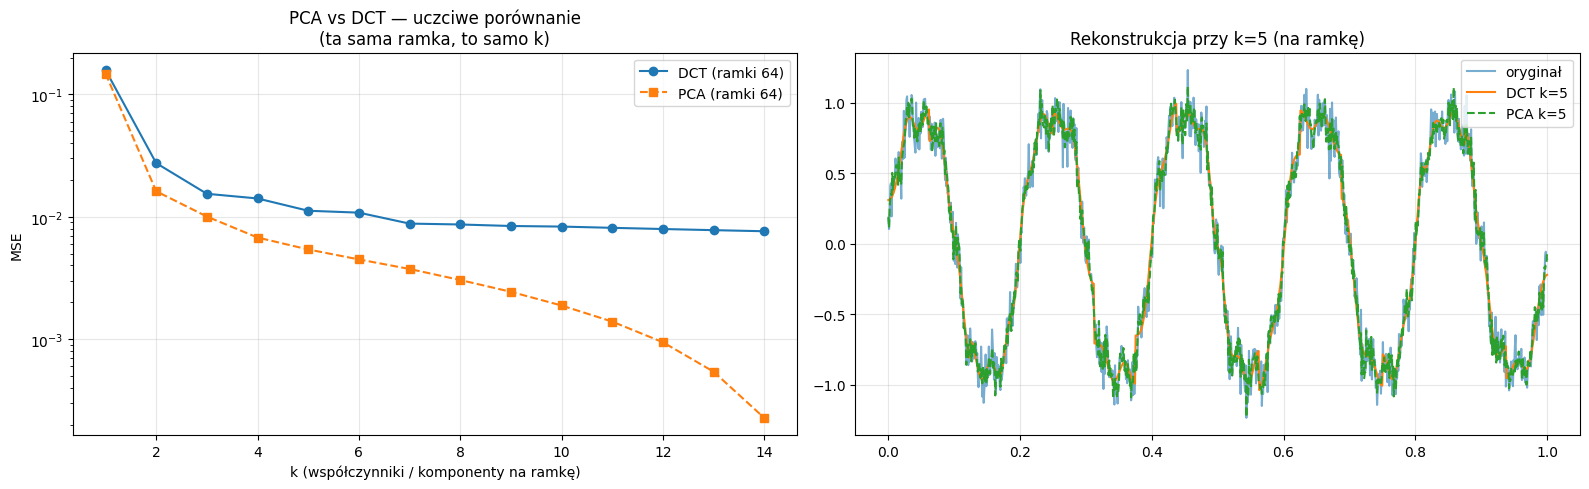

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(ks, mse_dct_list, 'o-', label="DCT (ramki 64)")
axes[0].plot(ks, mse_pca_list, 's--', label="PCA (ramki 64)")
axes[0].set_xlabel("k (współczynniki / komponenty na ramkę)")
axes[0].set_ylabel("MSE")
axes[0].set_yscale("log")
axes[0].set_title("PCA vs DCT — uczciwe porównanie\n(ta sama ramka, to samo k)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

k_show = 5

W_show = Vt.T[:, :k_show]
sig_pca_show = (X_centered @ W_show @ W_show.T + mean).flatten()

rec_frames_show = []
for frame in frames:
    c = dct(frame, norm="ortho")
    c[k_show:] = 0
    rec_frames_show.append(idct(c, norm="ortho"))
sig_dct_show = np.array(rec_frames_show).flatten()

axes[1].plot(t, signal, label="oryginał", alpha=0.6)
axes[1].plot(t, sig_dct_show, label=f"DCT k={k_show}", lw=1.5)
axes[1].plot(t, sig_pca_show, label=f"PCA k={k_show}", lw=1.5, ls='--')
axes[1].set_title(f"Rekonstrukcja przy k={k_show} (na ramkę)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

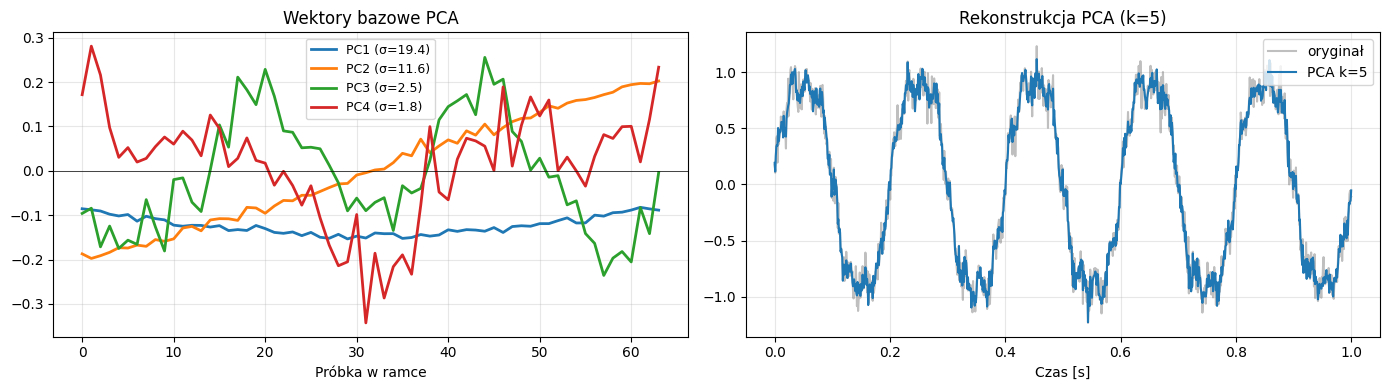

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# --- Wykres 1: wektory bazowe ---
n_show = 4
x_axis = np.arange(frame_size)
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

for i in range(n_show):
    axes[0].plot(x_axis, Vt[i], color=colors[i], lw=2, label=f"PC{i+1} (σ={S[i]:.1f})")

axes[0].set_title("Wektory bazowe PCA")
axes[0].set_xlabel("Próbka w ramce")
axes[0].axhline(0, color='black', lw=0.5)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# --- Wykres 2: rekonstrukcja PCA ---
k_show = 5
sig_pca_show = (X_centered @ Vt.T[:, :k_show] @ Vt[:k_show] + mean).flatten()

axes[1].plot(t, signal, label="oryginał", alpha=0.5, color='gray')
axes[1].plot(t, sig_pca_show, label=f"PCA k={k_show}", lw=1.5, color='tab:blue')
axes[1].set_title(f"Rekonstrukcja PCA (k={k_show})")
axes[1].set_xlabel("Czas [s]")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

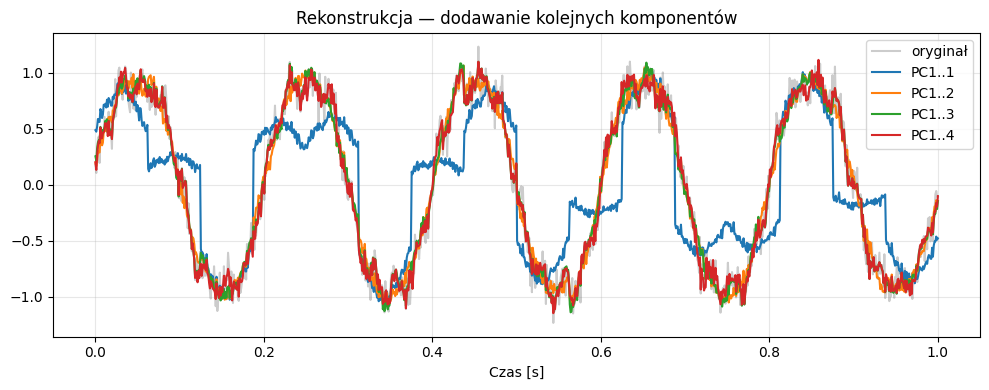

In [14]:
fig, axes = plt.subplots(1, 1, figsize=(10, 4))

axes.plot(t, signal, label="oryginał", alpha=0.4, color='gray')

for k_show in [1, 2, 3, 4]:
    rec = (X_centered @ Vt.T[:, :k_show] @ Vt[:k_show] + mean).flatten()
    axes.plot(t, rec, label=f"PC1..{k_show}", lw=1.5)

axes.set_title("Rekonstrukcja — dodawanie kolejnych komponentów")
axes.set_xlabel("Czas [s]")
axes.legend()
axes.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Analiza wyników: PCA vs DCT

Otrzymane wyniki pokazują zależność błędu rekonstrukcji (MSE) od liczby współczynników k dla dwóch metod redukcji wymiarowości: PCA oraz DCT. Widać wyraźnie, że PCA bardzo szybko osiąga niemal idealną rekonstrukcję – już przy k ≈ 30 błąd spada praktycznie do zera (~1e-30) i nie zmienia się przy dalszym zwiększaniu liczby wymiarów. Oznacza to, że rzeczywista struktura danych jest niskowymiarowa i PCA potrafi ją w pełni uchwycić.

Wynika to z faktu, że PCA dopasowuje się do danych i znajduje kierunki maksymalnej wariancji. W analizowanym przypadku sygnał składa się z kilku sinusoid oraz niewielkiego szumu, co oznacza, że jego efektywny wymiar jest mały. PCA „uczy się” tej struktury i potrafi ją idealnie odtworzyć przy stosunkowo niewielkiej liczbie komponentów.

Z kolei DCT zachowuje się inaczej – błąd maleje stopniowo wraz ze wzrostem k, ale znacznie wolniej niż w PCA. Wynika to z tego, że DCT nie dopasowuje się do danych, lecz korzysta z ustalonej bazy funkcji cosinus. Jest to metoda uniwersalna, ale mniej optymalna dla konkretnego sygnału.

Wyniki są poprawne i zgodne z teorią: PCA daje najlepszą możliwą kompresję dla danych, ponieważ jest metodą adaptacyjną, natomiast DCT jest metodą ogólną, która nie wykorzystuje specyficznej struktury sygnału.

Pojawia się więc pytanie: skoro PCA daje lepsze wyniki, to dlaczego w praktyce używa się DCT? Odpowiedź wynika z aspektów obliczeniowych i praktycznych. PCA wymaga obliczenia rozkładu SVD lub wartości własnych macierzy kowariancji, co jest kosztowne obliczeniowo (rzędu O(n³)). DCT natomiast można obliczyć bardzo szybko (O(n log n)) dzięki algorytmom podobnym do FFT. Dodatkowo PCA wymaga „uczenia się” na danych, podczas gdy DCT działa natychmiast i zawsze w ten sam sposób. To sprawia, że DCT jest stabilne, szybkie i łatwe do implementacji, dlatego jest wykorzystywane w standardach takich jak JPEG czy MP3.

Podsumowując: PCA zapewnia najlepszą jakość redukcji wymiarowości dla danego zbioru danych, natomiast DCT oferuje kompromis między jakością a wydajnością obliczeniową, co czyni je bardziej praktycznym rozwiązaniem w rzeczywistych zastosowaniach.

Dalsze eksperymenty mogą obejmować zmianę rodzaju sygnału (np. na losowy), zwiększenie poziomu szumu, analizę wykresu MSE w funkcji k oraz porównanie czasu działania obu metod. Pozwoli to lepiej zrozumieć, w jakich sytuacjach każda z metod sprawdza się najlepiej.